Loading normalized cost matrices...
Loading slices for layer labels...


/home/salovjade/miniconda3/envs/scanit-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/salovjade/miniconda3/envs/scanit-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Constructing same-layer mask...
Sampling cost values...

=== OLD cost ===
Same-layer  mean   : 0.0864
Same-layer  median : 0.0488
Diff-layer  mean   : 0.3126
Diff-layer  median : 0.1721
Mean gap (diff - same): 0.2262
Cohen's d           : 1.0169
AUROC (same-layer discrimination): 0.7913

=== NEW cost ===
Same-layer  mean   : 0.1363
Same-layer  median : 0.1103
Diff-layer  mean   : 0.4882
Diff-layer  median : 0.4584
Mean gap (diff - same): 0.3519
Cohen's d           : 1.8415
AUROC (same-layer discrimination): 0.9094

=== Summary ===
AUROC improvement: +0.1181


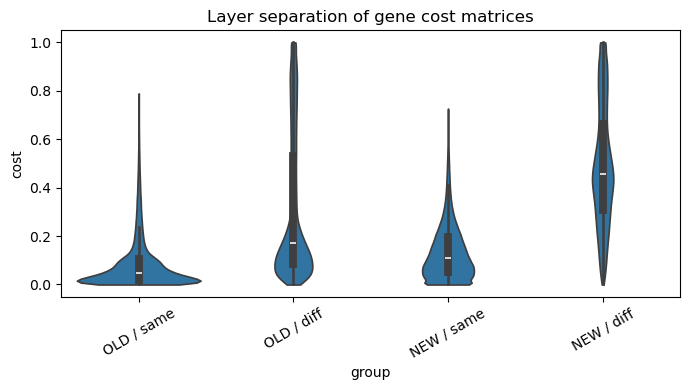


✅ Done.


In [1]:
# ============================================================
# Compare two gene cost matrices by layer discrimination power
# ============================================================

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score

pair = [151673, 151674]

# ------------------------------------------------------------
# Configuration (EDIT THESE)
# ------------------------------------------------------------
PATH_OLD = f"OutputEmbed/{pair[0]}_{pair[1]}_somde_cost_matrix.pt"
PATH_NEW = f"outputEmbed_updated_0122/{pair[0]}_{pair[1]}_somde_cost_matrix.pt"

ROOT_DIR = "/home/salovjade/0324_raftupdata/DLPFC12"
SECTION_A = pair[0]
SECTION_B = pair[1]

MAX_SAMPLES = 300_000   # subsampling for efficiency
RANDOM_SEED = 0


# ------------------------------------------------------------
# Load DLPFC slice (only for labels)
# ------------------------------------------------------------
def load_DLPFC(root_dir, section_id):
    adata = sc.read_visium(
        path=f"{root_dir}/{section_id}",
        count_file=f"{section_id}_filtered_feature_bc_matrix.h5",
    )
    adata.var_names_make_unique()

    gt = pd.read_csv(
        f"{root_dir}/{section_id}/gt/tissue_positions_list_GTs.txt",
        sep=",",
        header=None,
        index_col=0,
    )

    adata.obs["original_clusters"] = gt.loc[:, 6]
    adata = adata[adata.obs["original_clusters"].notna()].copy()
    adata.obs["original_clusters"] = (
        adata.obs["original_clusters"].astype(int).astype(str)
    )
    return adata


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def normalize_cost(
    C,
    mode="robust_minmax",
    q_low=0.01,
    q_high=0.99,
    max_samples=1_000_000,
    eps=1e-12,
):
    """
    Normalize cost matrix with optional robust min-max normalization.

    Parameters
    ----------
    C : torch.Tensor
        Cost matrix (n_a × n_b), on CPU.
    mode : str
        one of {"none", "minmax", "robust_minmax", "row_minmax"}
    max_samples : int
        Max number of entries used to estimate quantiles.
    """
    C = C.clone().float()

    if mode == "none":
        return C

    if mode == "minmax":
        return (C - C.min()) / (C.max() - C.min() + eps)

    if mode == "robust_minmax":
        flat = C.flatten()

        # ---- subsample for quantile estimation ----
        if flat.numel() > max_samples:
            idx = torch.randperm(flat.numel())[:max_samples]
            flat_sample = flat[idx]
        else:
            flat_sample = flat

        lo = torch.quantile(flat_sample, q_low)
        hi = torch.quantile(flat_sample, q_high)

        C = torch.clamp(C, lo, hi)
        return (C - lo) / (hi - lo + eps)

    if mode == "row_minmax":
        row_min = C.min(dim=1, keepdim=True).values
        row_max = C.max(dim=1, keepdim=True).values
        return (C - row_min) / (row_max - row_min + eps)

    raise ValueError(f"Unknown mode: {mode}")

def sample_costs(C, same_mask, max_samples, seed=0):
    rng = np.random.default_rng(seed)

    flat_C = C.flatten()
    flat_mask = same_mask.flatten()

    same_idx = np.where(flat_mask)[0]
    diff_idx = np.where(~flat_mask)[0]

    ns = min(len(same_idx), max_samples)
    nd = min(len(diff_idx), max_samples)

    same = flat_C[rng.choice(same_idx, ns, replace=False)]
    diff = flat_C[rng.choice(diff_idx, nd, replace=False)]

    return same.numpy(), diff.numpy()


def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x) + (ny - 1) * np.var(y)) / (nx + ny - 2)
    )
    return (np.mean(y) - np.mean(x)) / pooled_std


def summarize(name, same, diff):
    print(f"\n=== {name} ===")
    print(f"Same-layer  mean   : {same.mean():.4f}")
    print(f"Same-layer  median : {np.median(same):.4f}")
    print(f"Diff-layer  mean   : {diff.mean():.4f}")
    print(f"Diff-layer  median : {np.median(diff):.4f}")
    print(f"Mean gap (diff - same): {diff.mean() - same.mean():.4f}")
    print(f"Cohen's d           : {cohens_d(same, diff):.4f}")

    y_true = np.concatenate([np.ones(len(same)), np.zeros(len(diff))])
    scores = np.concatenate([-same, -diff])
    auc = roc_auc_score(y_true, scores)
    print(f"AUROC (same-layer discrimination): {auc:.4f}")

    return auc


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if __name__ == "__main__":

    print("Loading normalized cost matrices...")
    C_old = torch.load(PATH_OLD, map_location="cpu")
    C_new = torch.load(PATH_NEW, map_location="cpu")
    C_old = normalize_cost(C_old, mode="robust_minmax")
    C_new = normalize_cost(C_new, mode="robust_minmax")

    assert C_old.shape == C_new.shape, "Shape mismatch!"

    print("Loading slices for layer labels...")
    sliceA = load_DLPFC(ROOT_DIR, SECTION_A)
    sliceB = load_DLPFC(ROOT_DIR, SECTION_B)

    labelsA = np.array(sliceA.obs["original_clusters"])
    labelsB = np.array(sliceB.obs["original_clusters"])

    print("Constructing same-layer mask...")
    same_layer_mask = (labelsA[:, None] == labelsB[None, :])

    print("Sampling cost values...")
    same_old, diff_old = sample_costs(
        C_old, same_layer_mask, MAX_SAMPLES, RANDOM_SEED
    )
    same_new, diff_new = sample_costs(
        C_new, same_layer_mask, MAX_SAMPLES, RANDOM_SEED
    )

    # --------------------------------------------------------
    # Quantitative comparison
    # --------------------------------------------------------
    auc_old = summarize("OLD cost", same_old, diff_old)
    auc_new = summarize("NEW cost", same_new, diff_new)

    print("\n=== Summary ===")
    print(f"AUROC improvement: {auc_new - auc_old:+.4f}")

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------
    df = pd.DataFrame({
        "cost": np.concatenate([same_old, diff_old, same_new, diff_new]),
        "group": (
            ["OLD / same"] * len(same_old)
            + ["OLD / diff"] * len(diff_old)
            + ["NEW / same"] * len(same_new)
            + ["NEW / diff"] * len(diff_new)
        )
    })

    plt.figure(figsize=(7, 4))
    sns.violinplot(data=df, x="group", y="cost", cut=0)
    plt.xticks(rotation=30)
    plt.title("Layer separation of gene cost matrices")
    plt.tight_layout()
    plt.show()

    print("\n✅ Done.")

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# 1. 收集 same / diff cost
# --------------------------------------------------
def collect_cost_by_layer(
    C,
    labels_A,
    labels_B,
    max_per_group=20000,
):
    """
    Build a dataframe with columns:
    [layer, group (same/diff), cost]
    """
    labels_A = np.asarray(labels_A)
    labels_B = np.asarray(labels_B)

    rows = []
    unique_layers = np.unique(labels_A)

    for layer in unique_layers:
        idx_A = np.where(labels_A == layer)[0]
        idx_B_same = np.where(labels_B == layer)[0]
        idx_B_diff = np.where(labels_B != layer)[0]

        if len(idx_A) == 0:
            continue

        # same-layer
        if len(idx_B_same) > 0:
            costs_same = C[np.ix_(idx_A, idx_B_same)].flatten()
            if len(costs_same) > max_per_group:
                costs_same = np.random.choice(costs_same, max_per_group, replace=False)
            for c in costs_same:
                rows.append((layer, "same", float(c)))

        # diff-layer
        if len(idx_B_diff) > 0:
            costs_diff = C[np.ix_(idx_A, idx_B_diff)].flatten()
            if len(costs_diff) > max_per_group:
                costs_diff = np.random.choice(costs_diff, max_per_group, replace=False)
            for c in costs_diff:
                rows.append((layer, "diff", float(c)))

    df = pd.DataFrame(rows, columns=["layer", "group", "cost"])
    return df


# --------------------------------------------------
# 2. 主函数：画 boxplot
# --------------------------------------------------
def plot_layer_cost_boxplot(
    C,
    sliceA,
    sliceB,
    title="Cost matrix: same vs different layers",
    figsize=(10, 5),
):
    labels_A = sliceA.obs["original_clusters"].astype(str).values
    labels_B = sliceB.obs["original_clusters"].astype(str).values

    df = collect_cost_by_layer(C, labels_A, labels_B)

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=df,
        x="layer",
        y="cost",
        hue="group",
        showfliers=False,
    )

    plt.xlabel("cell_type / layer")
    plt.ylabel("Cost value")
    plt.title(title)
    plt.legend(title="group")
    plt.tight_layout()
    plt.show()

    return df

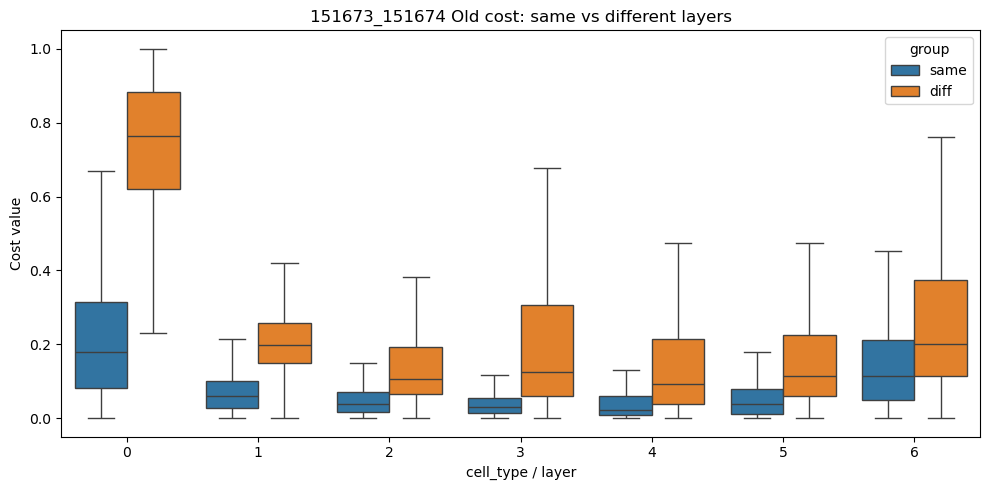

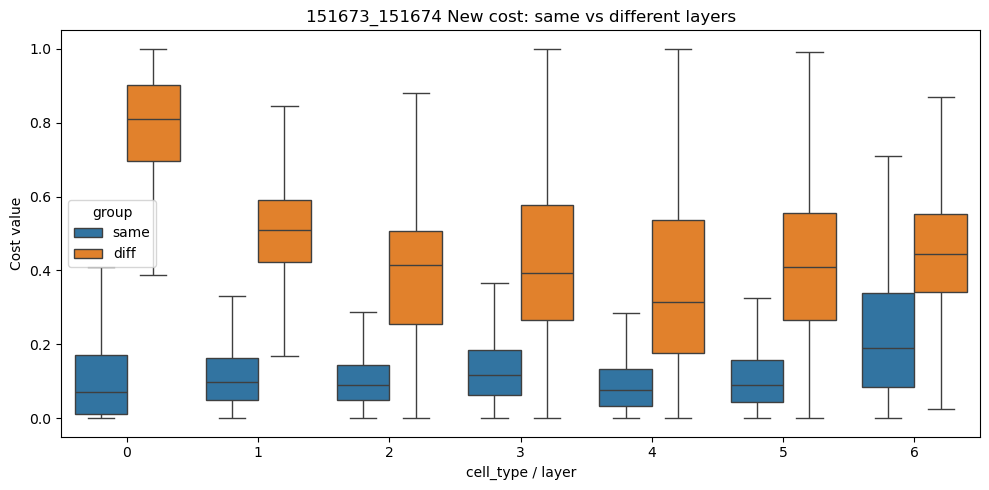

,layer,group,cost
0,0,same,0.000000
1,0,same,0.061111
2,0,same,0.160423
3,0,same,0.271127
4,0,same,0.057224
...,...,...,...
279995,6,diff,0.045565
279996,6,diff,0.357700
279997,6,diff,0.146619
279998,6,diff,0.762634


In [3]:
# 假设你已经有
# C_old, C_new
# sliceA, sliceB

# （可选）先 normalize
# C_old = normalize_cost(C_old, mode="robust_minmax")
# C_new = normalize_cost(C_new, mode="robust_minmax")

# 画图
plot_layer_cost_boxplot(
    C_old,
    sliceA,
    sliceB,
    title=f"{pair[0]}_{pair[1]} Old cost: same vs different layers",
)

plot_layer_cost_boxplot(
    C_new,
    sliceA,
    sliceB,
    title=f"{pair[0]}_{pair[1]} New cost: same vs different layers",
)

In [4]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# 工具：随机抽样避免爆内存
# -------------------------
def sample_pairs(labels_A, labels_B, n_samples=2000000, seed=0):
    rng = np.random.default_rng(seed)
    nA, nB = len(labels_A), len(labels_B)
    ia = rng.integers(0, nA, size=n_samples, endpoint=False)
    ib = rng.integers(0, nB, size=n_samples, endpoint=False)
    same = (labels_A[ia] == labels_B[ib]).astype(np.int8)
    return ia, ib, same

def normalize_simple(C):
    # 简单 min-max（不做quantile），你也可以不normalize
    Cmin = torch.min(C)
    Cmax = torch.max(C)
    return (C - Cmin) / (Cmax - Cmin + 1e-12)

# -------------------------
# 评估主函数
# -------------------------
def evaluate_cost_matrix(
    C,
    labels_A,
    labels_B,
    *,
    normalize=False,
    n_pair_samples=2000000,
    topk_list=(1,3,5,10),
    seed=0,
):
    """
    返回一个 dict：全局 AUROC/AUPRC + Hit@k + median gap (按layer及平均)
    """
    labels_A = np.asarray(labels_A).astype(str)
    labels_B = np.asarray(labels_B).astype(str)

    if normalize:
        C = normalize_simple(C)

    # -------- (1) AUROC / AUPRC 用随机pair抽样 --------
    ia, ib, y = sample_pairs(labels_A, labels_B, n_samples=n_pair_samples, seed=seed)
    # score 越大越像 same，因此用 -cost
    scores = (-C[torch.from_numpy(ia), torch.from_numpy(ib)]).numpy()

    auroc = roc_auc_score(y, scores)
    auprc = average_precision_score(y, scores)

    # -------- (2) Top-k hit rate（全量算，但只用topk索引，不会爆）--------
    hit_at_k = {}
    C_cpu = C  # assumed CPU already; if not, call .cpu()
    for k in topk_list:
        topk_idx = torch.topk(C_cpu, k, largest=False).indices  # (nA,k)
        hits = []
        for i in range(C_cpu.shape[0]):
            layer = labels_A[i]
            pred_layers = labels_B[topk_idx[i].numpy()]
            hits.append(np.any(pred_layers == layer))
        hit_at_k[k] = float(np.mean(hits))

    # -------- (3) Median gap：按layer抽样计算（避免巨大笛卡尔积）--------
    rng = np.random.default_rng(seed)
    layers = np.unique(labels_A)
    gaps = {}

    for layer in layers:
        idxA = np.where(labels_A == layer)[0]
        idxB_same = np.where(labels_B == layer)[0]
        idxB_diff = np.where(labels_B != layer)[0]
        if len(idxA)==0 or len(idxB_same)==0 or len(idxB_diff)==0:
            continue

        # 抽样 same
        n_s = min(200000, len(idxA)*len(idxB_same))
        ia_s = rng.choice(idxA, size=n_s, replace=True)
        ib_s = rng.choice(idxB_same, size=n_s, replace=True)
        same_cost = C_cpu[torch.from_numpy(ia_s), torch.from_numpy(ib_s)].numpy()

        # 抽样 diff
        n_d = min(200000, len(idxA)*len(idxB_diff))
        ia_d = rng.choice(idxA, size=n_d, replace=True)
        ib_d = rng.choice(idxB_diff, size=n_d, replace=True)
        diff_cost = C_cpu[torch.from_numpy(ia_d), torch.from_numpy(ib_d)].numpy()

        gaps[layer] = float(np.median(diff_cost) - np.median(same_cost))

    gap_mean = float(np.mean(list(gaps.values()))) if len(gaps)>0 else np.nan

    return {
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
        "Hit@k": hit_at_k,
        "MedianGap_mean": gap_mean,
        "MedianGap_by_layer": gaps,
        "normalize": normalize,
        "n_pair_samples": n_pair_samples,
    }

# -------------------------
# 对比 old vs new 的 wrapper
# -------------------------
def compare_two_costs(
    C_old, C_new,
    sliceA, sliceB,
    normalize=False,
    seed=0,
):
    labels_A = sliceA.obs["original_clusters"].astype(str).values
    labels_B = sliceB.obs["original_clusters"].astype(str).values

    r_old = evaluate_cost_matrix(C_old, labels_A, labels_B, normalize=normalize, seed=seed)
    r_new = evaluate_cost_matrix(C_new, labels_A, labels_B, normalize=normalize, seed=seed)

    print("=== Comparison (normalize =", normalize, ") ===")
    print("[OLD] AUROC:", r_old["AUROC"], " AUPRC:", r_old["AUPRC"], " MeanGap:", r_old["MedianGap_mean"])
    print("[NEW] AUROC:", r_new["AUROC"], " AUPRC:", r_new["AUPRC"], " MeanGap:", r_new["MedianGap_mean"])
    print("\nHit@k:")
    for k in sorted(r_old["Hit@k"].keys()):
        print(f"  Hit@{k}: old={r_old['Hit@k'][k]:.4f}  new={r_new['Hit@k'][k]:.4f}")

    return r_old, r_new

In [5]:
r_old, r_new = compare_two_costs(C_old, C_new, sliceA, sliceB, normalize=False)
r_old_n, r_new_n = compare_two_costs(C_old, C_new, sliceA, sliceB, normalize=True)

=== Comparison (normalize = False ) ===
[OLD] AUROC: 0.791928447928149  AUPRC: 0.45851930523169876  MeanGap: 0.1604467843260084
[NEW] AUROC: 0.9093188983963394  AUPRC: 0.6522790494150338  MeanGap: 0.366650721856526

Hit@k:
  Hit@1: old=0.7690  new=0.8064
  Hit@3: old=0.8759  new=0.8926
  Hit@5: old=0.9092  new=0.9205
  Hit@10: old=0.9551  new=0.9466
=== Comparison (normalize = True ) ===
[OLD] AUROC: 0.791928447928149  AUPRC: 0.45851930523169876  MeanGap: 0.1604467843260084
[NEW] AUROC: 0.9093188983963394  AUPRC: 0.6522790494150338  MeanGap: 0.366650721856526

Hit@k:
  Hit@1: old=0.7690  new=0.8064
  Hit@3: old=0.8759  new=0.8926
  Hit@5: old=0.9092  new=0.9205
  Hit@10: old=0.9551  new=0.9466
